In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import torch
import torch.nn as nn
import matplotlib.lines as mlines
import corner
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import sys
sys.path.append('../../')
import data.datasets as datasets
from models.losses import SupervisedSimCLRLoss,NPLMLoss
#from models.networks import CustomEfficientNet
from models.networks import MLP
from models.litmodels import SimCLRModel,LossCollector
import data.data_utils as dutils
from torch.utils.data import TensorDataset
from torch.utils.data import random_split
import lightning as pl

/home/pharris/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
# --- Selection & Mass Calculations ---
def compute_mass(E, px, py, pz):
    return np.sqrt(np.maximum(E**2 - px**2 - py**2 - pz**2, 0))

def compute_pair_mass(e1, px1, py1, pz1, e2, px2, py2, pz2):
    E = e1 + e2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2
    return np.sqrt(np.maximum(E**2 - px**2 - py**2 - pz**2, 0))

def compute_m4l(E, px, py, pz):
    E_tot = np.sum(E, axis=1)
    px_tot = np.sum(px, axis=1)
    py_tot = np.sum(py, axis=1)
    pz_tot = np.sum(pz, axis=1)
    return np.sqrt(np.maximum(E_tot**2 - px_tot**2 - py_tot**2 - pz_tot**2, 0))


def has_ossf(row):
    leptons = [row[f'PID{i}'] for i in range(1, 5)]
    for i, j in combinations(range(4), 2):
        pid_i = leptons[i]
        pid_j = leptons[j]
        # Same flavor (abs equal), opposite sign
        if abs(pid_i) == abs(pid_j) and pid_i * pid_j < 0:
            return True
    return False

def has_z_candidate(row):
    for i, j in combinations(range(1, 5), 2):
        pid_i = row[f'PID{i}']
        pid_j = row[f'PID{j}']
        if abs(pid_i) == abs(pid_j) and pid_i * pid_j < 0:
            mll = compute_pair_mass(
                row[f'E{i}'], row[f'px{i}'], row[f'py{i}'], row[f'pz{i}'],
                row[f'E{j}'], row[f'px{j}'], row[f'py{j}'], row[f'pz{j}']
            )
            if 60 < mll < 120:
                return True
    return False

def select_higgs_candidates(df):
    E  = df[['E1', 'E2', 'E3', 'E4']].values
    px = df[['px1', 'px2', 'px3', 'px4']].values
    py = df[['py1', 'py2', 'py3', 'py4']].values
    pz = df[['pz1', 'pz2', 'pz3', 'pz4']].values
    df['m4l'] = compute_m4l(E, px, py, pz)
    
    df = df[df.apply(has_ossf, axis=1)]
    df = df[df.apply(has_z_candidate, axis=1)]
    df = df[(df['m4l'] > 70) & (df['m4l'] < 180)]
    return df


def pt(px, py):
    return np.sqrt(px**2 + py**2)

def find_ossf_pairs(row):
    """Find all OSSF lepton pairs. Return list of (i, j) indices."""
    pairs = []
    for i, j in combinations(range(1, 5), 2):
        pid_i = row[f'PID{i}']
        pid_j = row[f'PID{j}']
        if abs(pid_i) == abs(pid_j) and pid_i * pid_j < 0:
            pairs.append((i, j))
    return pairs

def select_higgs_candidates(df):
    # Invariant mass
    E = df[[f'E{i}' for i in range(1, 5)]].values
    px = df[[f'px{i}' for i in range(1, 5)]].values
    py = df[[f'py{i}' for i in range(1, 5)]].values
    pz = df[[f'pz{i}' for i in range(1, 5)]].values
    df['m4l'] = compute_m4l(E, px, py, pz)

    selected_rows = []

    for idx, row in df.iterrows():
        ossf_pairs = find_ossf_pairs(row)

        # Require ≥2 OSSF pairs
        if len(ossf_pairs) < 1:
            continue

        # Compute invariant masses for all OSSF pairs
        pair_masses = []
        for i, j in ossf_pairs:
            mll = compute_pair_mass(
                row[f'E{i}'], row[f'px{i}'], row[f'py{i}'], row[f'pz{i}'],
                row[f'E{j}'], row[f'px{j}'], row[f'py{j}'], row[f'pz{j}']
            )
            pair_masses.append(((i, j), mll))

        # Sort to find Z1 (closest to Z mass)
        pair_masses.sort(key=lambda x: abs(x[1] - 91.2))
        (i1, j1), mZ1 = pair_masses[0]
        used_indices = {i1, j1}

        # Find next OSSF pair not overlapping Z1
        mZ2 = None
        for (i, j), mass in pair_masses[1:]:
            if i not in used_indices and j not in used_indices:
                mZ2 = mass
                break

        if mZ2 is None:
            continue

        # ChatGPT (loose mode)
        #if not (70 < mZ1 < 110):
        #    continue
        #if not (4 < mZ2 < 120):
        #    continue

       #CMS
        if not (50 < mZ1 < 120):
            continue
        if not (12 < mZ2 < 120):
            continue

        # Loosened lepton pT cuts
        pts = [pt(row[f'px{i}'], row[f'py{i}']) for i in range(1, 5)]
        pts.sort(reverse=True)
        #if not (pts[0] > 10 and pts[1] > 5 and pts[2] > 5 and pts[3] > 5): #ChatGPT (Loose mode)
        if not (pts[0] > 20 and pts[1] > 10 and pts[2] > 5 and pts[3] > 5): #CMS
            continue
        
        # 4l mass window
        if not (70 < row['m4l'] < 180): #70-180
            continue

        selected_rows.append(row)

    return pd.DataFrame(selected_rows)

# --- Load and Process Datasets ---
def load_sample(filename, xsec, ngen, lumi):
    df = pd.read_csv(filename)
    df = select_higgs_candidates(df)
    weight = (xsec * lumi) / ngen if ngen > 0 else 0
    df['weight'] = weight
    print(filename,len(df))
    return df['m4l'].values, df['weight'].values


MC/zzto4e2012.csv 16367
MC/zzto2mu2e2012.csv 13554
MC/zzto4mu2012.csv 29684
MC/dy50_2012.csv 3
MC/zzto4e2011.csv 22002
MC/zzto2mu2e2011.csv 17019
MC/zzto4mu2011.csv 34129
MC/ttbar2011.csv 20
MC/dy50_2011.csv 10


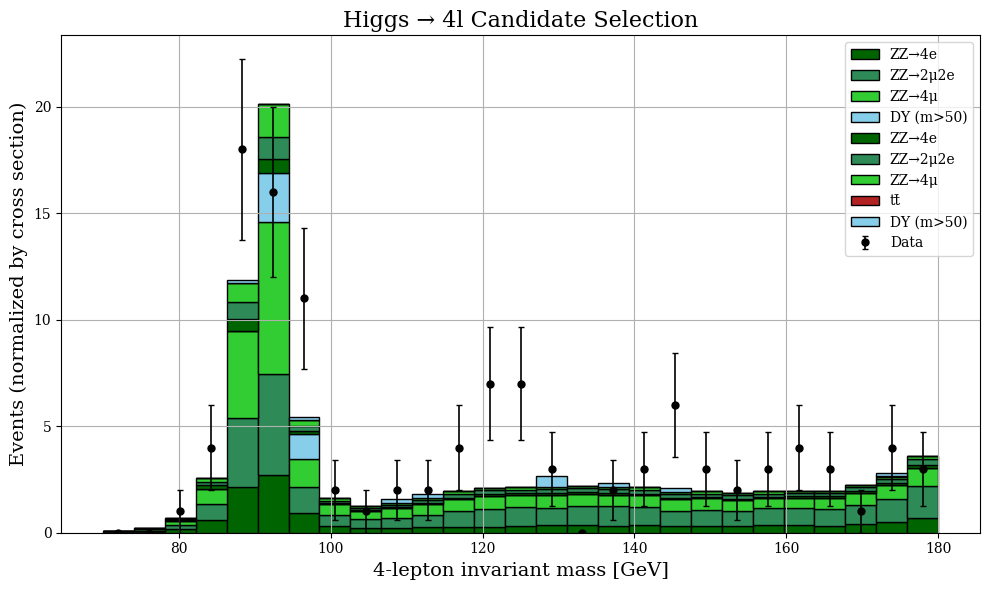

In [3]:
# --- Parameters: cross sections, event counts, lumi ---
lumi = 11580. 
xszzto4e  = 0.107
xszzto4mu = 0.107
xszzto2mu2e = 0.249
xsttbar   = 200.
xsdy50    = 2955.
xsdy1050  = 10.742

nzzto4mu   = 1499064
nzzto4e    = 1499093
nzzto2mu2e = 1497445
nttbar     = 6423106
ndy50      = 29426492
ndy1050    = 6462290

# --- Load all MC samples ---
hist_data = []
labels = []
colors = []

sample_info_12 = {
    "ZZ→4e":     ("MC/zzto4e2012.csv",     "darkgreen",  xszzto4e,     nzzto4e),
    "ZZ→2μ2e":   ("MC/zzto2mu2e2012.csv",  "seagreen",   xszzto2mu2e,  nzzto2mu2e),
    "ZZ→4μ":     ("MC/zzto4mu2012.csv",    "limegreen",  xszzto4mu,    nzzto4mu),
#    "tt̄":        ("MC/ttbar2012.csv",      "firebrick",  xsttbar,      nttbar),
    "DY (m>50)": ("MC/dy50_2012.csv",       "skyblue",    xsdy50,       ndy50),
#    "DY (10<m<50)": ("MC/dy1050_2012.csv",  "dodgerblue", xsdy1050,     ndy1050),
}

for label, (file, color, xsec, ngen) in sample_info_12.items():
    m4l, weights = load_sample(file, xsec, ngen, lumi)
    hist_data.append((m4l, weights))
    labels.append(label)
    colors.append(color)

# --- Load data sample ---
df_data = pd.read_csv("Data/clean_data_2012.csv")
df_data = select_higgs_candidates(df_data)
m4l_data_12 = df_data['m4l'].values

lumi = 2330. #11
xszzto4e  = 0.093
xszzto4mu = 0.093
xszzto2mu2e = 0.208
xsttbar   = 19.504
xsdy50    = 2475.
xsdy1050  = 9507.


nzzto4mu   = 1447136
nzzto4e    = 1493308
nzzto2mu2e = 1479879
nttbar     = 9771205
ndy50      = 36408225
ndy1050    = 39909640

sample_info_11 = {
    "ZZ→4e":     ("MC/zzto4e2011.csv",     "darkgreen",  xszzto4e,     nzzto4e),
    "ZZ→2μ2e":   ("MC/zzto2mu2e2011.csv",  "seagreen",   xszzto2mu2e,  nzzto2mu2e),
    "ZZ→4μ":     ("MC/zzto4mu2011.csv",    "limegreen",  xszzto4mu,    nzzto4mu),
    "tt̄":        ("MC/ttbar2011.csv",      "firebrick",  xsttbar,      nttbar),
    "DY (m>50)": ("MC/dy50_2011.csv",       "skyblue",    xsdy50,       ndy50),
#    "DY (10<m<50)": ("MC/dy1050_2011.csv",  "dodgerblue", xsdy1050,     ndy1050),
}

# --- Load data sample ---
df_data = pd.read_csv("Data/clean_data_2011.csv")
df_data = select_higgs_candidates(df_data)
m4l_data = df_data['m4l'].values
m4l_data = np.append(m4l_data,m4l_data_12)

bins = np.linspace(70, 180, 28)  # 2 GeV bin width

for label, (file, color, xsec, ngen) in sample_info_11.items():
    m4l, weights = load_sample(file, xsec, ngen, lumi)
    hist_data.append((m4l, weights))
    labels.append(label)
    colors.append(color)

# --- Plot stacked histogram ---

plt.figure(figsize=(10, 6))
plt.hist(
    [d[0] for d in hist_data],
    bins=bins,
    weights=[d[1] for d in hist_data],
    stacked=True,
    label=labels,
    color=colors,
    edgecolor='black'
)

# --- Bin the data (using same bin edges as MC) ---
counts_data, bin_edges = np.histogram(m4l_data, bins=bins)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
errors = np.sqrt(counts_data)  # Poisson errors

# --- Plot data with markers + error bars ---
plt.errorbar(
    bin_centers,
    counts_data,
    yerr=errors,
    fmt='o',
    color='black',
    markersize=5,
    label='Data',
    capsize=2,
    elinewidth=1.2
)

plt.xlabel("4-lepton invariant mass [GeV]", fontsize=14)
plt.ylabel("Events (normalized by cross section)", fontsize=14)
plt.title("Higgs → 4l Candidate Selection", fontsize=16)
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig(“higgs_stacked_histogram.png”)
plt.show()

In [4]:
xshiggs11 = 0.0057
xshiggs12 = 0.0065
lumi11    = 2330.
lumi12    = 11580.
nhiggs11  = 299683
nhiggs12   = 299973
sig_sample_info = {
    "h→4l 2011":         ("MC/higgs2011.csv",  "red", xshiggs11,     nhiggs11,4),
    "h→4l 2012":         ("MC/higgs2012.csv",  "red", xshiggs12,     nhiggs12,4),
}
sig_hist_data=[]
for label, (file, color, xsec, ngen, pId) in sig_sample_info.items():
    lumi=lumi11
    if "2012" in label:
        lumi=lumi12
    m4l, weights = load_sample(file, xsec, ngen, lumi)
    sig_hist_data.append((m4l, weights))
mc_sig=[]
mc_sig_weights=[]
for pData in sig_hist_data:
    mc_sig.extend(pData[0].flatten())
    mc_sig_weights.extend(pData[1].flatten())
mc_sig=torch.tensor(mc_sig,dtype=torch.float64)
mc_sig_weights=torch.tensor(mc_sig_weights, dtype=torch.float64)
mc_sig=mc_sig.unsqueeze(-1)

MC/higgs2011.csv 41640
MC/higgs2012.csv 33194


In [5]:
mc=[]
mc_weights=[]
for pData in hist_data:
    mc.extend(pData[0].flatten())
    mc_weights.extend(pData[1].flatten())
mc=torch.tensor(mc,dtype=torch.float64)
mc_weights=torch.tensor(mc_weights, dtype=torch.float64)
mc=mc.unsqueeze(-1)

epoch: 1, NPLM loss: 0.000000, COEFFS: 0.000000


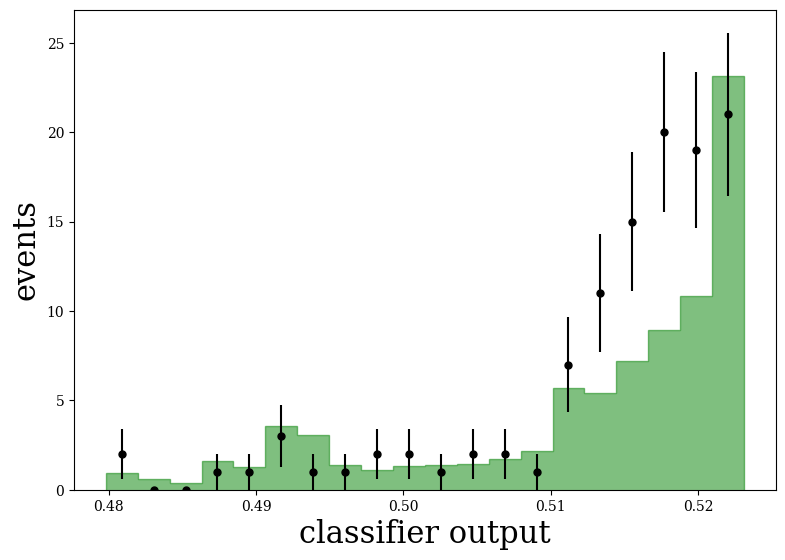

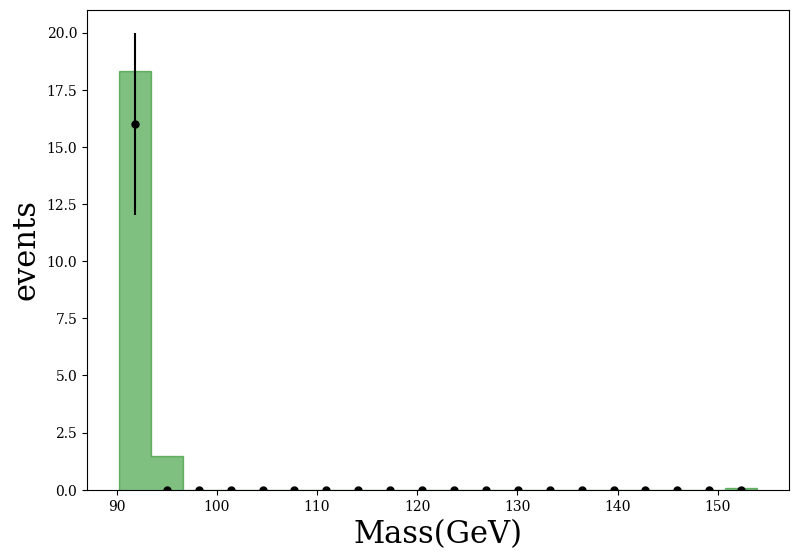

<Figure size 800x600 with 0 Axes>

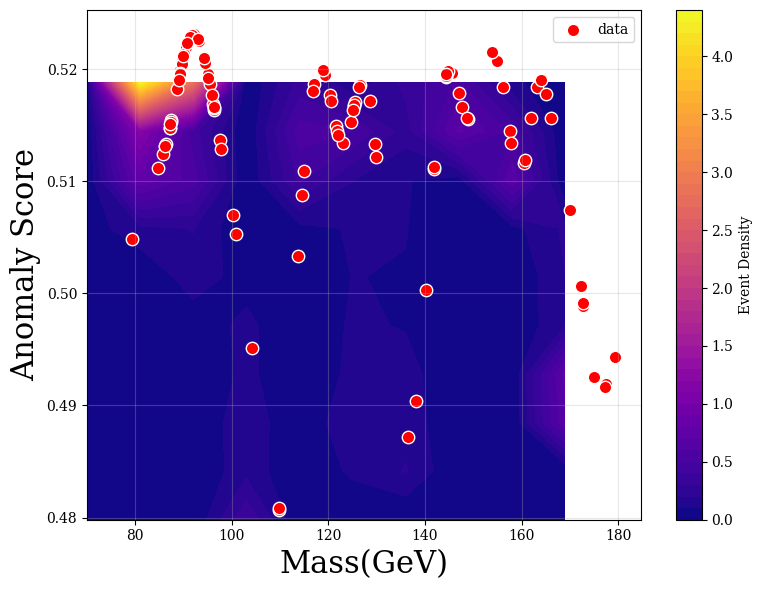

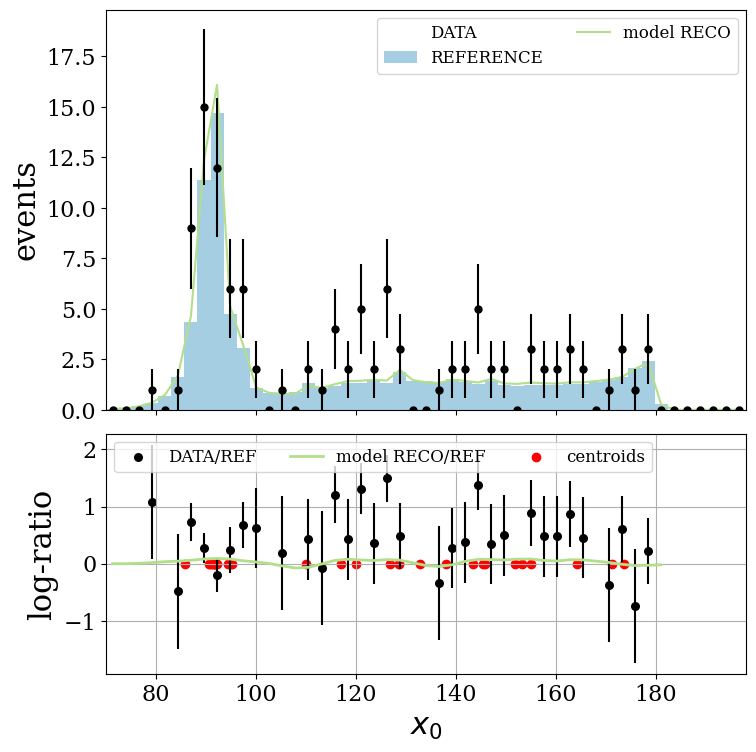

epoch: 501, NPLM loss: -17.632063, COEFFS: 0.000000


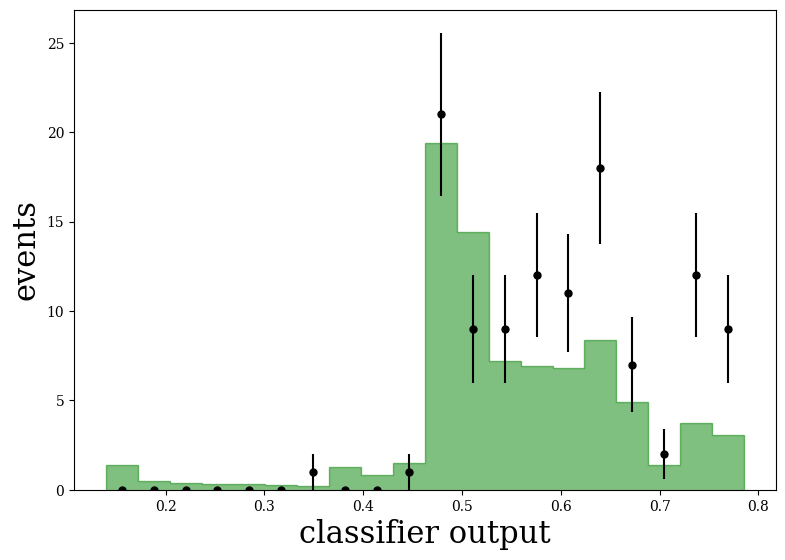

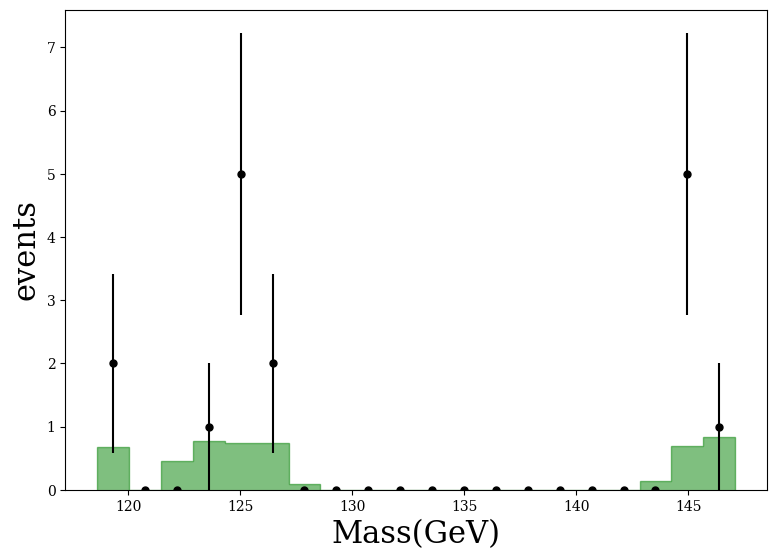

<Figure size 800x600 with 0 Axes>

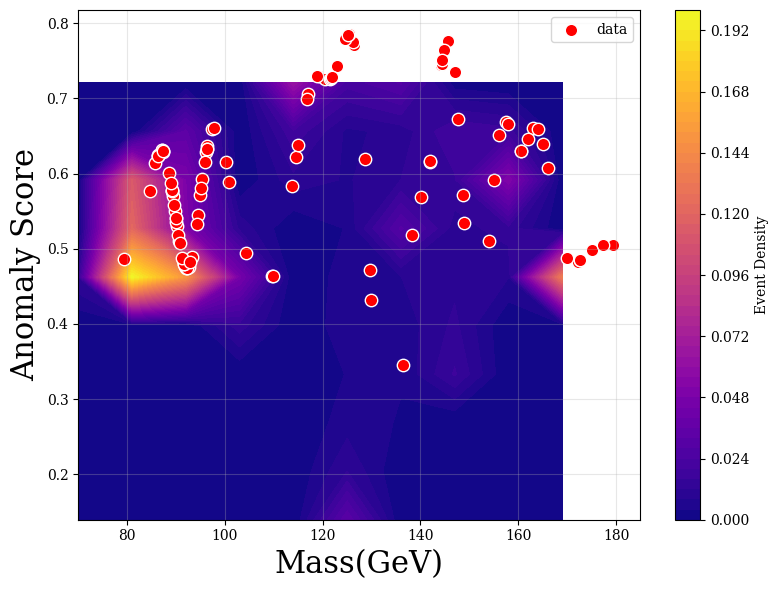

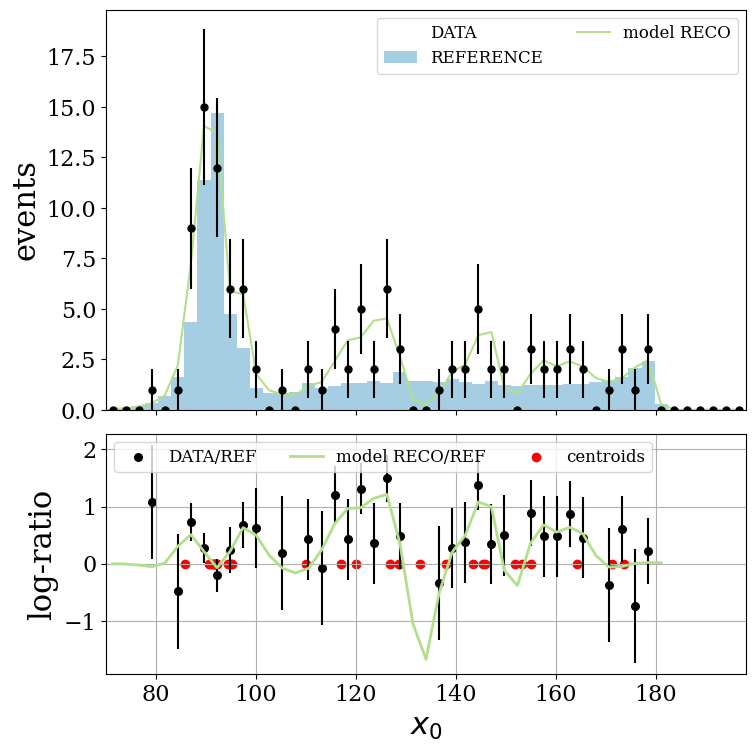

epoch: 1001, NPLM loss: -18.309341, COEFFS: 0.000000


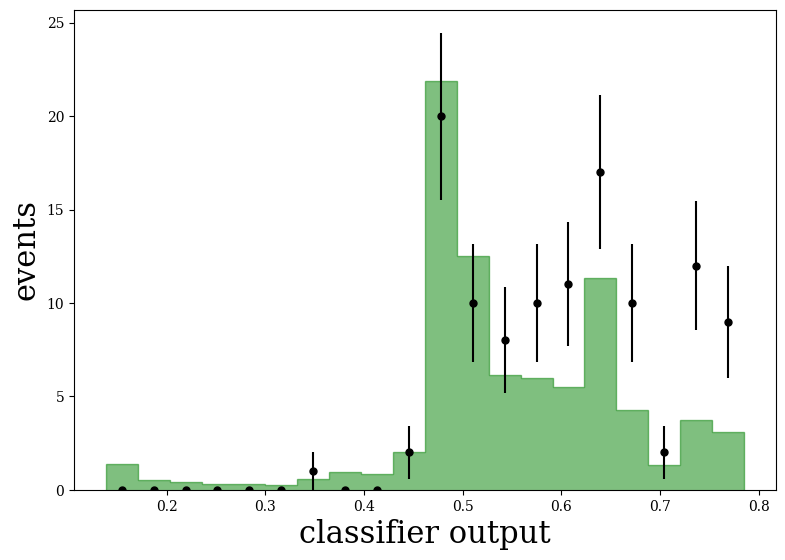

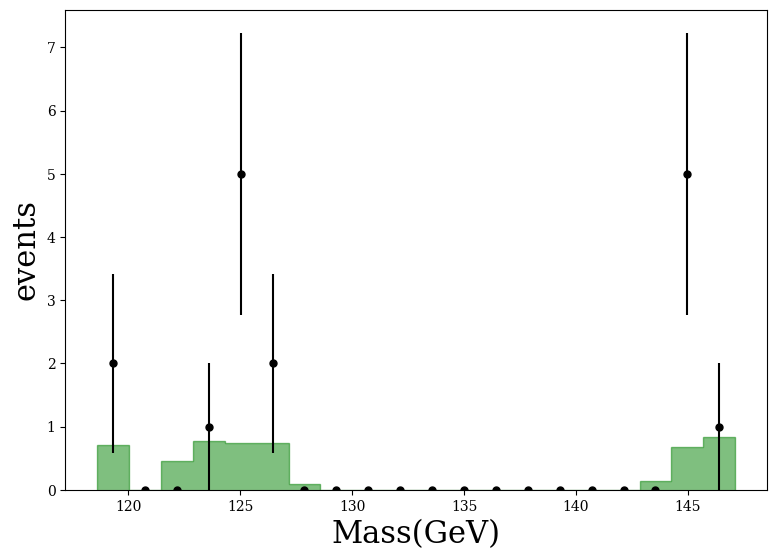

<Figure size 800x600 with 0 Axes>

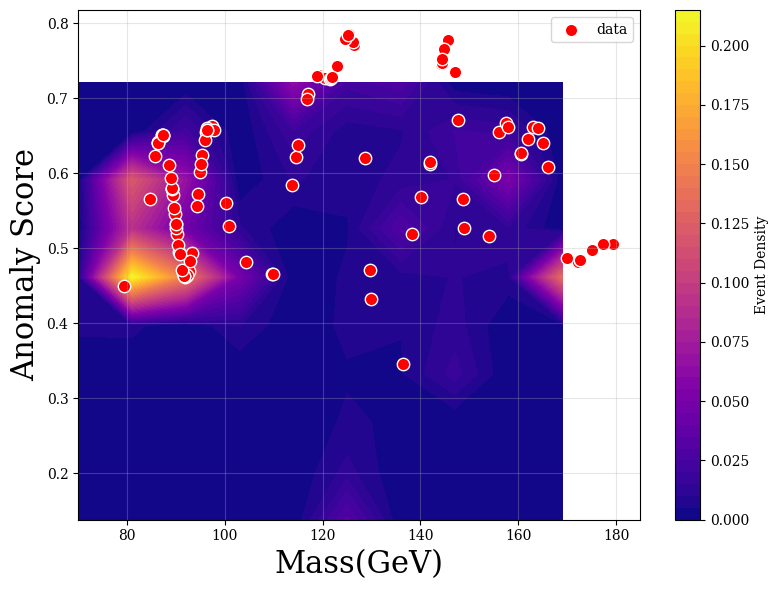

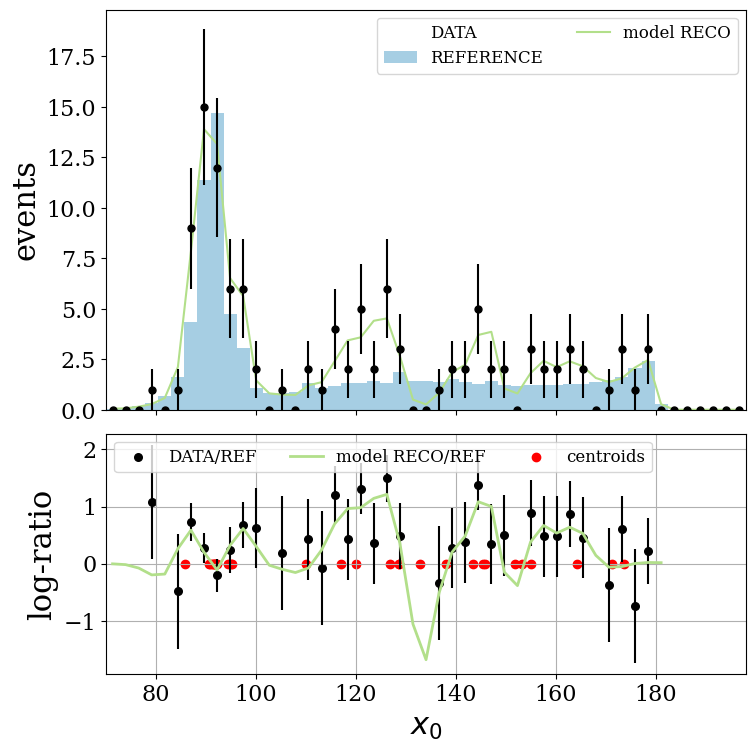

36.618681914511384

In [13]:
from utils.PLOTutils import plot_training_data
data      = torch.tensor(m4l_data,dtype=torch.float64)
d_weights = torch.ones(data.shape[0],dtype=torch.float64)
data=data.unsqueeze(-1)
dutils.sparkKer(data, mc, mc, -1, d_weights, mc_weights,splitmass=False,iWidth_init=[4])


In [6]:
#split MCs into data and ref for fitting 
def splitInTwo(iArr,iWeight):
    print(iArr.size(0),iWeight.size(0))
    perm_sig = torch.randperm(iArr.size(0))
    half_sig = iArr.size(0) // 2
    sig1_idx = perm_sig[:half_sig]
    sig2_idx = perm_sig[half_sig:]
    out1=iArr[sig1_idx].detach()
    out2=iArr[sig2_idx].detach()
    wout1=iWeight[sig1_idx].detach()
    wout2=iWeight[sig2_idx].detach()
    return out1,wout1*2,out2,wout2*2


mc_short   = mc[mc_weights < 0.1]
mc_weights_short = mc_weights[mc_weights < 0.1]
mc_data, mcw_data, mc_model, mcw_model=splitInTwo(mc_short,mc_weights_short)
sig_data,sigw_data,sig_model,sigw_model=splitInTwo(mc_sig,mc_sig_weights)

#combine all MCs together with signal and bkg labels
def combineSigMC(iSig,iSWeight,iMC,iMCWeight):
    mc_labels       = torch.zeros(iMC.shape[0],dtype=torch.float32).detach()
    mc_sig_labels   = torch.ones(iSig.shape[0],dtype=torch.float32).detach()
    mc_total        = torch.cat((iMC,iSig)).detach()
    mc_total_labels = torch.cat((mc_labels,mc_sig_labels)).detach()
    mc_total_weight = torch.cat((iMCWeight,iSWeight)).detach()
    return mc_total,mc_total_labels,mc_total_weight

bdata, bdata_labels, bdata_weights =combineSigMC(sig_data, sigw_data, mc_data,mcw_data)
bmodel,bmodel_labels,bmodel_weights=combineSigMC(sig_model,sigw_model,mc_model,mcw_model)


data_dict={}
data_dict["toy_data_out"]     = bdata
data_dict["toy_data_label"]   = bdata_labels
data_dict["toy_data_weights"] = bdata_weights

data_dict["toy_mc_out"]       = bmodel
data_dict["toy_mc_label"]     = bmodel_labels
data_dict["toy_mc_weights"]   = bmodel_weights
np.savez("higgs_base_space_tight.npz", **data_dict)



132775 132775
74834 74834


nsig tensor(10.4529, dtype=torch.float64) nbkg tensor(138.8700, dtype=torch.float64)
epoch: 1, NPLM loss: 0.000000, COEFFS: 0.000000


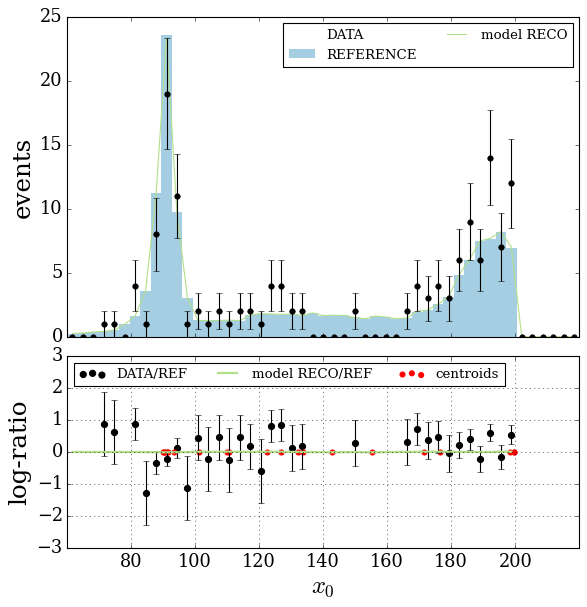

epoch: 1001, NPLM loss: -14.877900, COEFFS: 0.000000


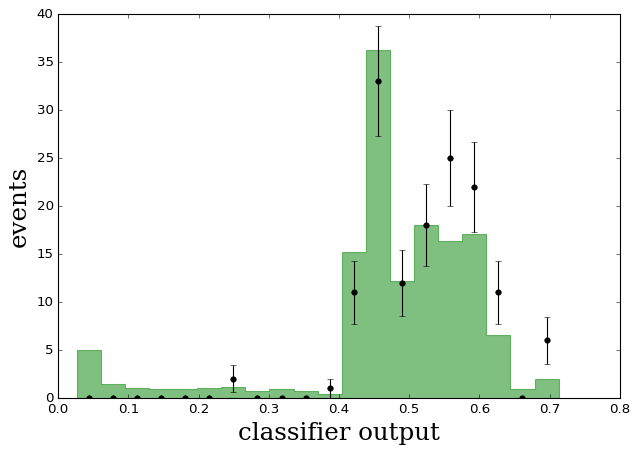

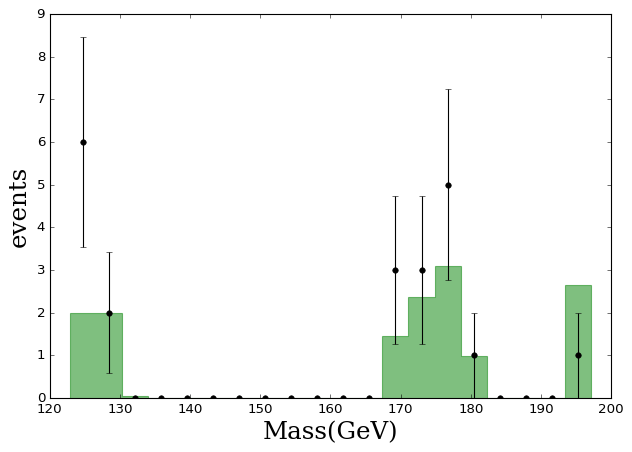

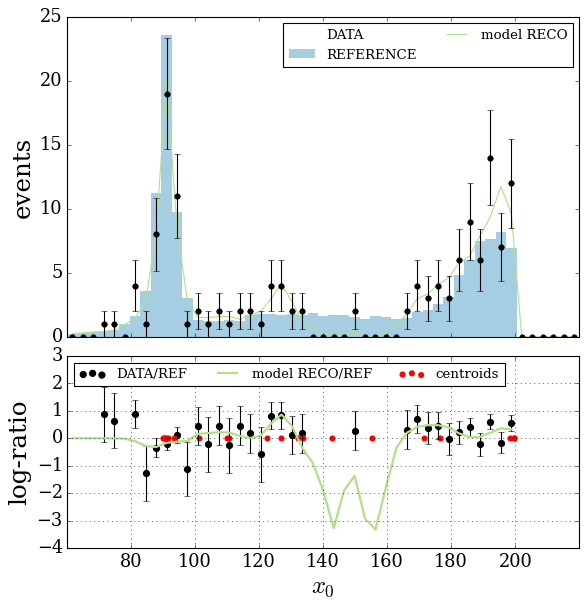

epoch: 1, NPLM loss: 0.000000, COEFFS: 0.000000


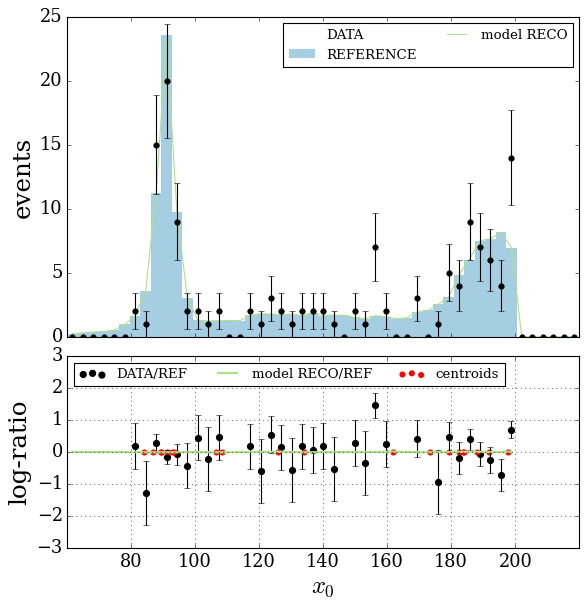

epoch: 1001, NPLM loss: -4.502362, COEFFS: 0.000000


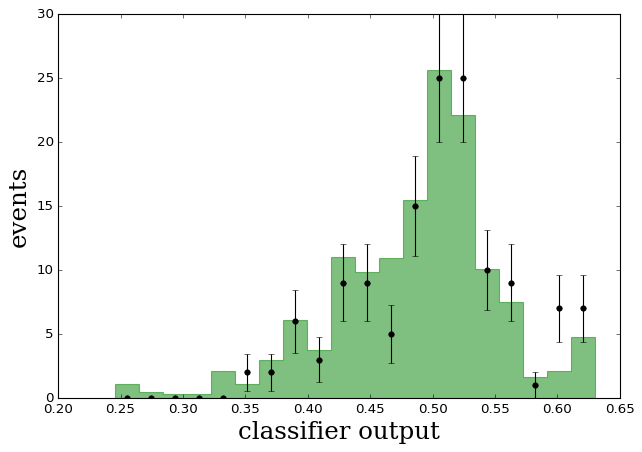

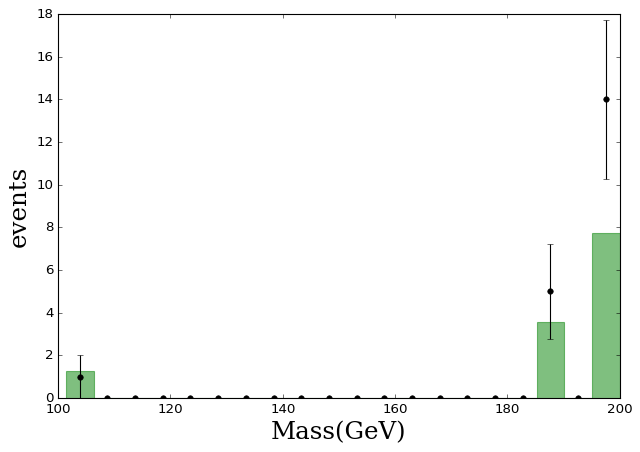

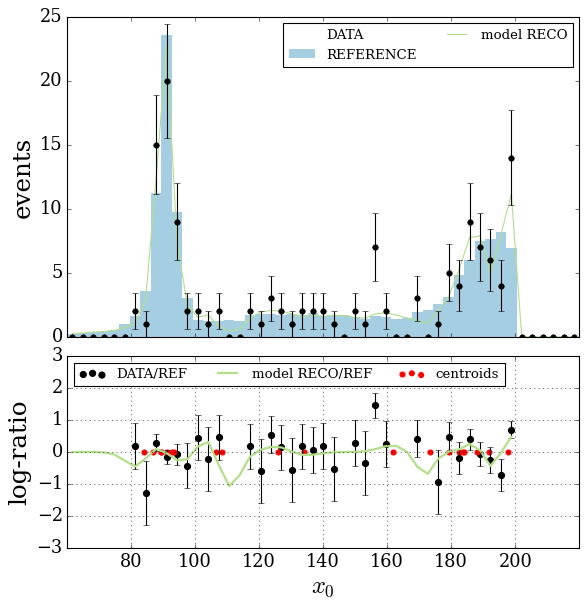

toy: 29.755799246839512 9.004724670839344 !
epoch: 1, NPLM loss: 0.000000, COEFFS: 0.000000


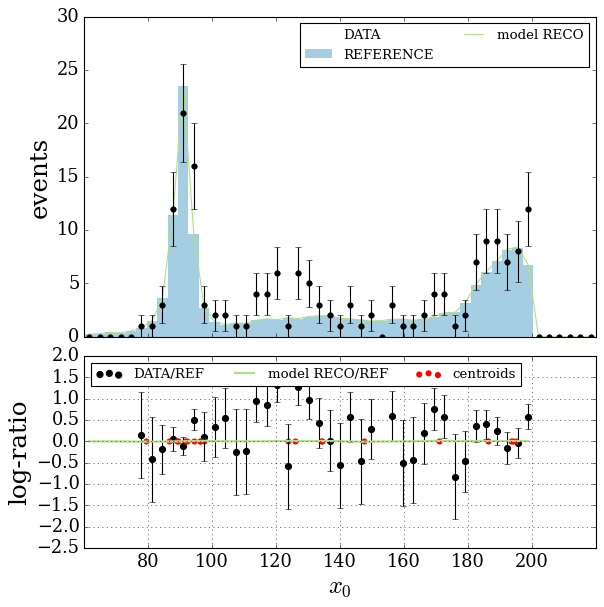

epoch: 1001, NPLM loss: -10.559949, COEFFS: 0.000000


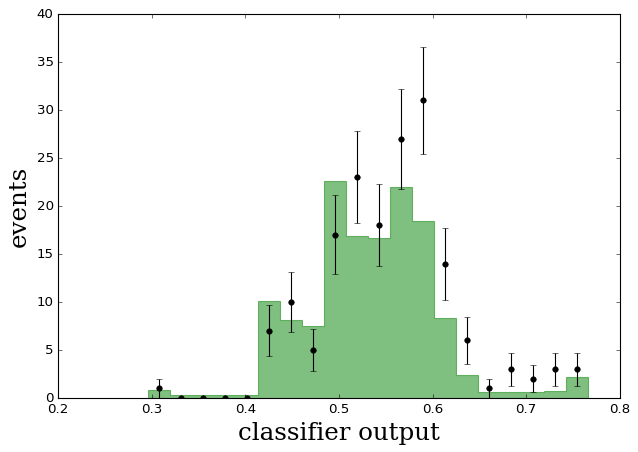

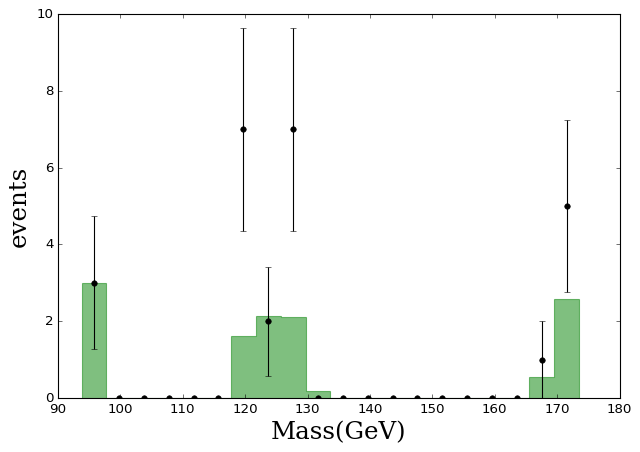

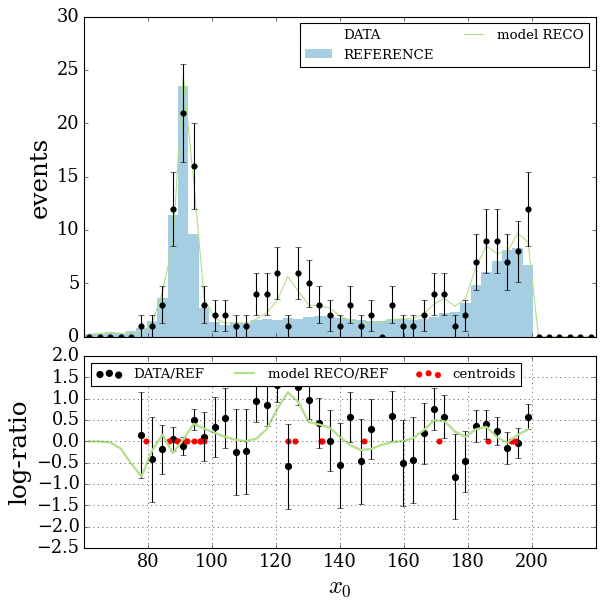

epoch: 1, NPLM loss: 0.000000, COEFFS: 0.000000


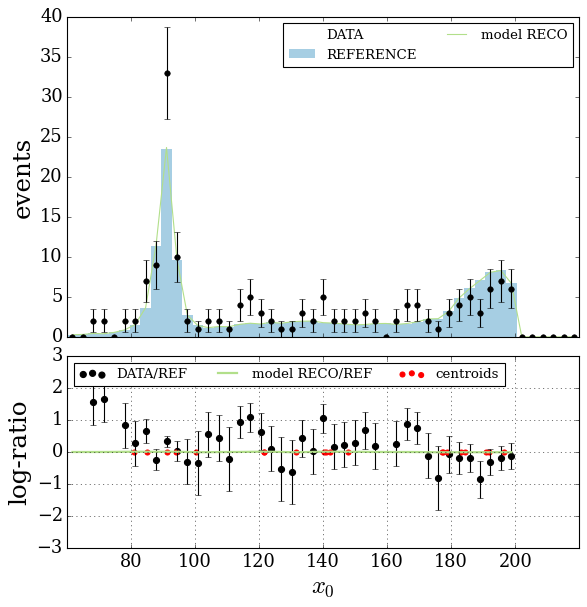

epoch: 1001, NPLM loss: -10.512381, COEFFS: 0.000000


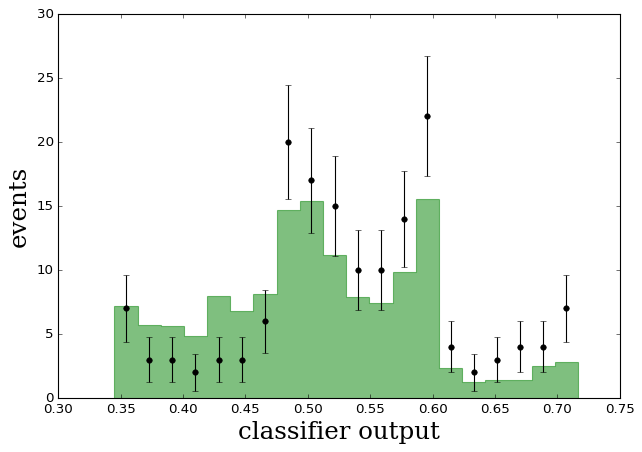

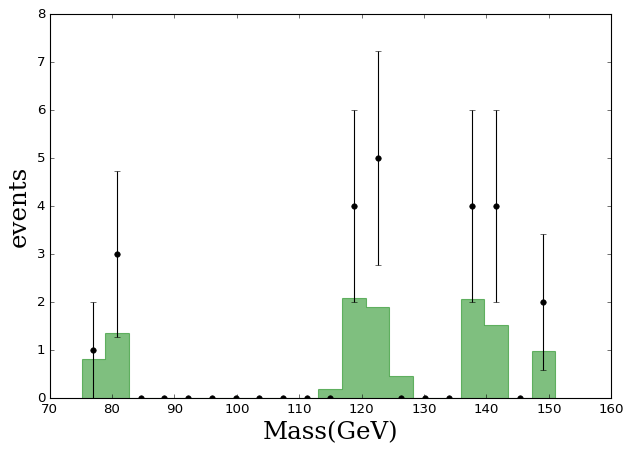

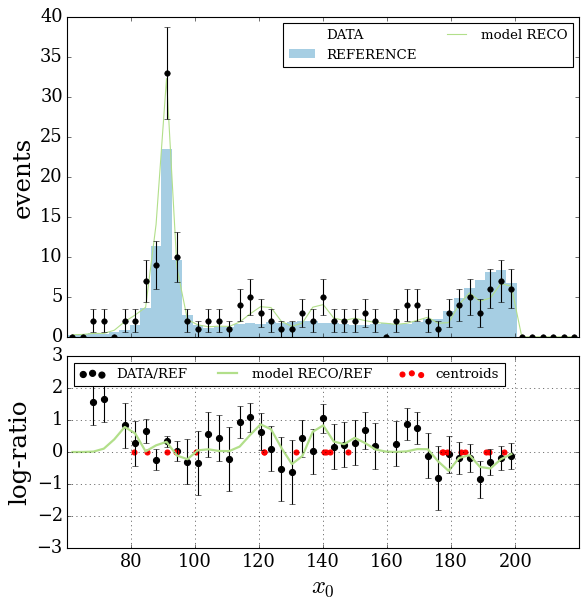

toy: 21.119897629430273 21.024762798469464 !


In [7]:
lOption=2
iNToys=2
sig_idx=1
nref=40000
tr,td=dutils.run_realistic_toy(nref,bdata, bdata_labels,bmodel, bmodel_labels,
                                sig_idx,data_weights=bdata_weights.double(),model_weights=bmodel_weights.double(),
                                ntoys=iNToys,plot=True,splitmass=False,width=4.)
#print(tr,td)
data_dict={}
data_dict["toy_higgs"] = tr
data_dict["toy_bkg"]   = td
np.savez("higgs_base_toys_500_v4.npz", **data_dict)

In [ ]:
sig_vals,bins=np.histogram(td,bins=20)
bkg_vals,bins=np.histogram(tr,bins=bins)
#diff_vals,bins=np.histogram(file["toy_sig"]-file["toy_bkg"],bins=bins)
bin_center = 0.5*(bins[1:]+bins[:-1])
plt.stairs(bkg_vals,bins,label='bkg')
plt.stairs(sig_vals,bins,label='sig')
#plt.stairs(diff_vals,bins,label='diff')
plt.legend()
plt.show()

In [8]:
lOption=3
iNToys=500
sig_idx=1
nref=40000

tr,td=dutils.run_realistic_toy(nref,bdata, bdata_labels,bmodel, bmodel_labels,
                                sig_idx,data_weights=bdata_weights.double(),model_weights=bmodel_weights.double(),
                                ntoys=iNToys,plot=True,splitmass=False,width=4.,iOption=lOption)


nsig tensor(10.1439, dtype=torch.float64) nbkg tensor(78.4481, dtype=torch.float64)
toy: 1.8078190761936228 0.13595093376476947 !
toy: 2.535561520632102 0.16534950415902527 !
toy: 1.2038712523843915 -0.29262141197063396 !
toy: 2.374319928806487 6.296497357465298 !
toy: 3.0106966352605014 0.8023683268381768 !
toy: 1.7452664745880528 -1.3646560491664717 !
toy: 2.579873959188873 0.3110848869126756 !
toy: 2.0311639797289964 0.4657322891355617 !
toy: 2.7948950287223866 1.8511055580834506 !
toy: 2.433097166776866 -0.7561626837953134 !
toy: 1.0573246722405527 -0.8205446438815603 !
toy: 1.63873394026118 0.16330134044819627 !
toy: 3.566610390944478 -1.281179237613946 !
toy: 2.31635086282337 1.5839990840076708 !
toy: 1.2994549677103975 0.23965385210615228 !
toy: 3.0820732609114256 -0.723488981899093 !
toy: 1.3209777121425161 0.21978548185804875 !
toy: 3.7455892199997356 -0.02343335212973287 !
toy: 2.3607471798717916 -1.9223227705043293 !
toy: 1.2862036422955123 0.3953803611417792 !
toy: 1.129158

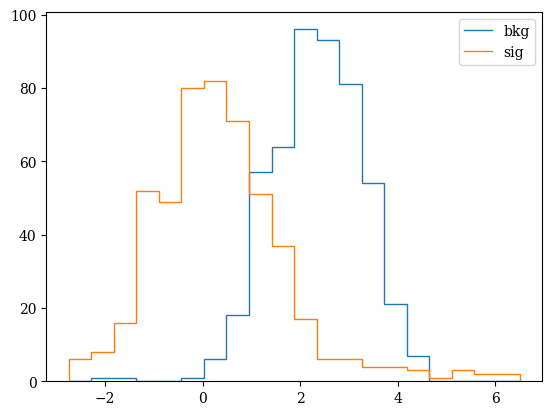

In [10]:
clean_td = td[np.isfinite(td)]
clean_tr = tr[np.isfinite(td)]
data_dict={}
data_dict["toy_higgs"] = clean_tr
data_dict["toy_bkg"]   = clean_td
np.savez("higgs_base_nll_toys_tight.npz", **data_dict)

sig_vals,bins=np.histogram(clean_td,bins=20)
bkg_vals,bins=np.histogram(clean_tr,bins=bins)
#diff_vals,bins=np.histogram(file["toy_sig"]-file["toy_bkg"],bins=bins)
bin_center = 0.5*(bins[1:]+bins[:-1])
plt.stairs(bkg_vals,bins,label='bkg')
plt.stairs(sig_vals,bins,label='sig')
#plt.stairs(diff_vals,bins,label='diff')
plt.legend()
plt.show()

In [10]:
dutils.dLL_4lm(data, mc, mc_weights,mc_sig,mc_sig_weights)

np.float64(1.8218287770912265)